In [1]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

In [2]:
#Loading data from movie.csv
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4


# Data Analysis

## what does the data tell us and what insights can we get from it to maximize profits? (total_gross)
-  genres vs average_rating - which genres are getting the best reviews? 

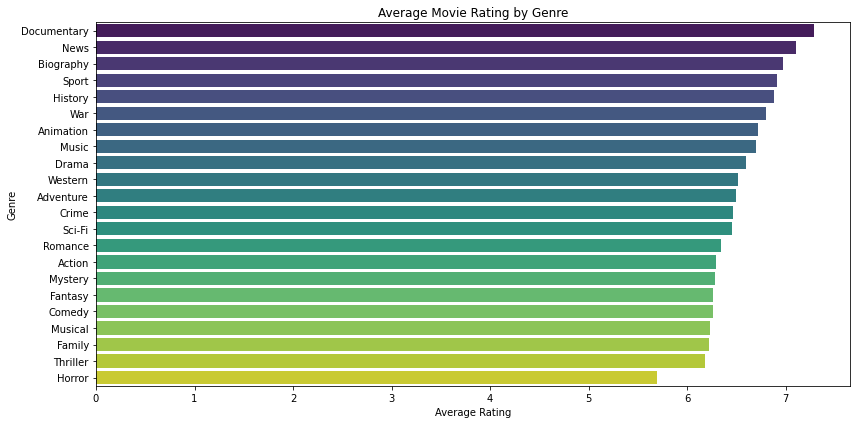

In [3]:
import ast
# Convert stringified lists into actual Python lists
df['genres'] = df['genres'].apply(ast.literal_eval)

# Explode the genres column
df_exploded = df.explode('genres')

# Group by genre and calculate average rating
genre_avg_rating = df_exploded.groupby('genres')['averagerating'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_avg_rating.values, y=genre_avg_rating.index, palette="viridis")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Average Movie Rating by Genre")
plt.tight_layout()
plt.show();

`Insights`
- Top rated genres such as Documentary, News and Biography have the highest average rating. 

`Recommendation`
The studio should invest in these top rated genres.


## how is the competition and what niches can we exploit for a start (studio)
 - runtime_category vs average_rating -> is there a correlation between runtime and average rating? and if so, how strong is it? and is it something to consider?

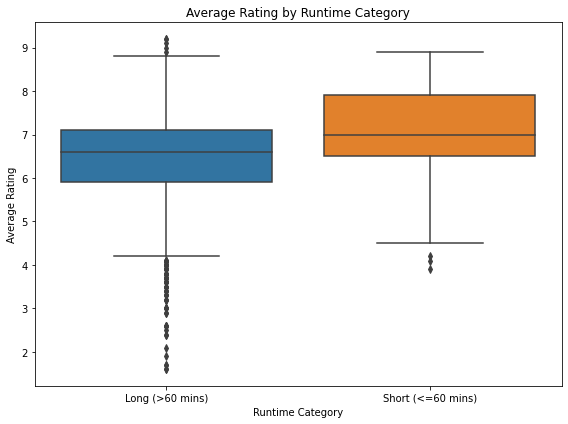

(0.14523856463260923, 7.19539093546647e-16)

In [4]:
from scipy.stats import pearsonr

# Categorize runtime
df['runtime_category'] = df['runtime_minutes'].apply(lambda x: 'Long (>60 mins)' if x > 60 else 'Short (<=60 mins)')

# Correlation between runtime and average rating
corr, p_value = pearsonr(df['runtime_minutes'], df['averagerating'])

# Plotting the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='runtime_category', y='averagerating', data=df)
plt.title('Average Rating by Runtime Category')
plt.xlabel('Runtime Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

corr, p_value

`Insights`
- There is a weak but consistent positive correlation (0.145) between runtime and average rating.
- Shorter movies tend to receive slightly higher ratings, on average.

`conclusion`:   The studio should prioritize feature-length productions (below 60 minutes), especially for the first impression.

## trends over time (year)
runtime_category vs year - split runtime into 2 categories: short and long. short = 0-60, long = 60+. -> is there a trend in runtime_category over the years and if so, is it something to consider?

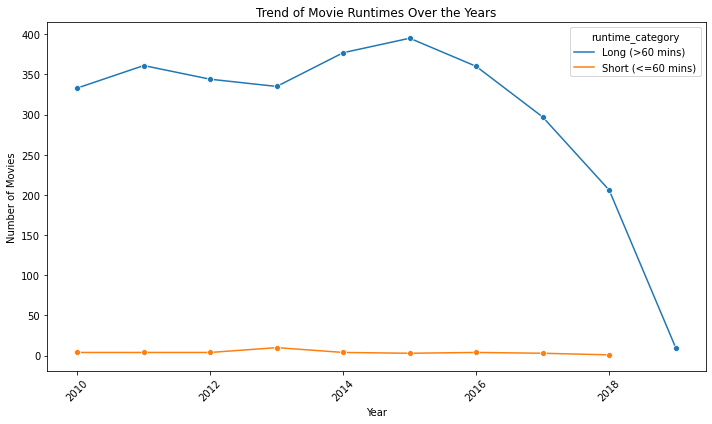

In [5]:
# Group by year and runtime category to count occurrences
runtime_trends = df.groupby(['year', 'runtime_category']).size().reset_index(name='count')

# Plotting the trend over years
plt.figure(figsize=(10, 6))
sns.lineplot(data=runtime_trends, x='year', y='count', hue='runtime_category', marker='o')
plt.title('Trend of Movie Runtimes Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


`Insights`
- While, long movies (> 60 mins) have become increasingly dominant over the years, there is a downward trend.

- However, short movies (≤ 60 mins) have steadily declined in frequency, especially in more recent years.

- For the studio, entering the market with short-length movies aligns with both current trends and audience expectations

## 3. Which factors are most associated with total box office revenue?"

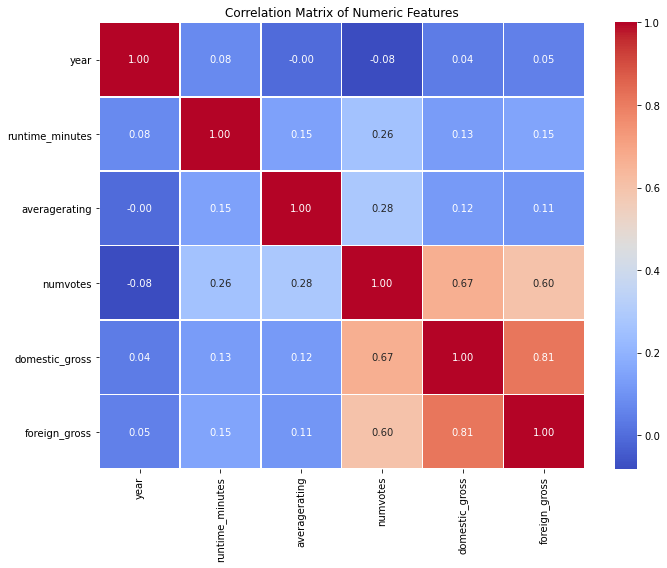

In [7]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

numvotes or popularity has a strong positive correlation (0.67 & 0.60) with domestic and foreign gross suggesting that the more the number of votes the revenue increases.


runtime minutes for a film have a weak positive correlation with the quantitative variables, so we cannot use it for our analysis. The runtime does not significantly impact a film's profitability or popularity